# Project Overview

## Latar Belakang

Performa akademik siswa dipengaruhi oleh berbagai faktor, seperti intensitas belajar, kualitas istirahat, aktivitas ekstrakurikuler, dan kebiasaan mengerjakan latihan soal. Dengan memanfaatkan teknik Machine Learning, hubungan antara faktor-faktor tersebut dapat dianalisis untuk membantu memprediksi tingkat performa siswa secara lebih objektif.

## Tujuan Proyek

Proyek ini bertujuan untuk membangun model prediksi menggunakan algoritma Multiple Linear Regression guna memprekirakan nilai Indeks Performa Siswa berdasarkan beberapa variabel yang mempengaruhinya

## Variabel yang Digunakan

Fitur yang digunakan dalam penelitian ini meliputi:
- Jam Belajar (Hours Studied)
- Nilai Sebelumnya (Previous Scores)
- Aktivitas Ektrakurikuler (Extracurricular Activities)
- Jam Tidur (Sleep Hours)
- Jumlah Latihan Soal yang Dikerjakan (Sample Question Papers Practiced)

Sedangkan variabel target yang akan diprediksi adalah:
- Indeks Performa Siswa (Performance Index)

## Metode

Model yang digunakan adalah Multiple Linear Regression, yaitu metode regresi yang digunakan untuk memprediksi nilai target berdasarkan lebih dari satu variabel independen. Metode ini dipilih karena mampu menjelaskan hubungan linier antara beberapa fitur dengan variabel target serta menghasilkan model yang mudah diintepretasikan.

## Outcome

Hasil dari proyek ini diharapkan dapat memberikan pemahaman mengenai faktor-faktor yang paling berpengaruh terhadap performa siswa sekaligus menghasilkan model prediksi dengan tingkat akurasi yang baik

## Workflow

1. Data Understanding
2. Data Cleaning
3. Explanatory Data Analysis
4. Feature Selection
5. Train-Test Split
6. Feature Scaling
7. Model Training
8. Model Evaluation
9. Prediction
10. Conclusion

# Import Library

pada tahap ini dilakukan import beberapa library yang dibutuhkan untuk proses analisis data, visualisasi, preprocessing, pembangunan model dan evaluasi model machine learning.

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

In [2]:
# Menampilkan seluruh kolom data frame
pd.set_option('display.max_columns', None)

# Mengatur Style Visualisasi
sns.set_style('whitegrid')

# Load Dataset

In [5]:
data_raw = pd.read_csv('../data/raw/Student_Performance.csv')

data = data_raw.copy()

In [6]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


# Data Understanding

In [7]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


Data ini berisi kolom: 
1. Jam Belajar
2. Nilai Sebelumnya
3. Kegiatan Extrakurikuler
4. Jam Tidur
5. Jumlah Latihan Soal yang Dikerjakan
6. Indeks Performa

Kolom yang menjadi target adalah kolom Indeks Performa (Performance Index)

Fitur Numerik yaitu semua fitur kecuali Kegiatan Extrakurikuler yang merupakan fitur kategorikal

In [ ]:
data.shape

(10000, 6)

jumlah baris dalam dataset ini ada 10000 baris dan 6 kolom

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB


semua tipe data masing masing kolom sudah benar

In [11]:
data.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


1. Nilai jam belajar berkisar antara 1 hingga 9 jam
2. Nilai sebelumnya berkisar antara 40 dan 99
3. jam tidur berkisar antara 4 jam sampai 9 jam
4. jumlah latihan soal yang dikerjakan berkisar antara 0 sampai 9 lembar soal
5. nilai indeks performa berkisar di 10 sampai 100

Tidak ditemukan nilai yang tampak tak wajar

Identifikasi Target dan Fitur:

fitur (X):
1. Jam belajar
2. Nilai Sebelumnya
3. Aktivitas Ekstrakurikuler
4. Jam Tidur
5. Latihan Soal

Target (Y):
- Indeks Performa

# Data Cleaning

Tujuan Data Cleaning adalah memastikan data yang akan masuk ke model benar-benar bersih dan konsisten.

## Missing Value

In [12]:
data_missing = data[data.isnull().any(axis=1)]
data_missing.shape

(0, 6)

Hasil pengecekan menunjukkan bahwa tidak terdapat missing value pada seluruh kolom dataset sehingga tidak diperlukan proses penanganan data kosong

## Duplicated Data

In [13]:
data_duplikat = data[data.duplicated()]
data_duplikat.shape

(127, 6)

Ditemukan 127 baris data duplikat pada dataset. Data Duplikat akan dihapus untuk menghindari bias pada proses pelatihan model

In [14]:
data = data.drop_duplicates()

## Data Type Validation

In [15]:
data.info()

<class 'pandas.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   str    
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
dtypes: float64(1), int64(4), str(1)
memory usage: 539.9 KB


Seluruh tipe data telah sesuai dengan karakteristik masing-masing variabel sehingga tidak diperlukan konversi tipe data

# Explanatory Data Analysis (EDA)

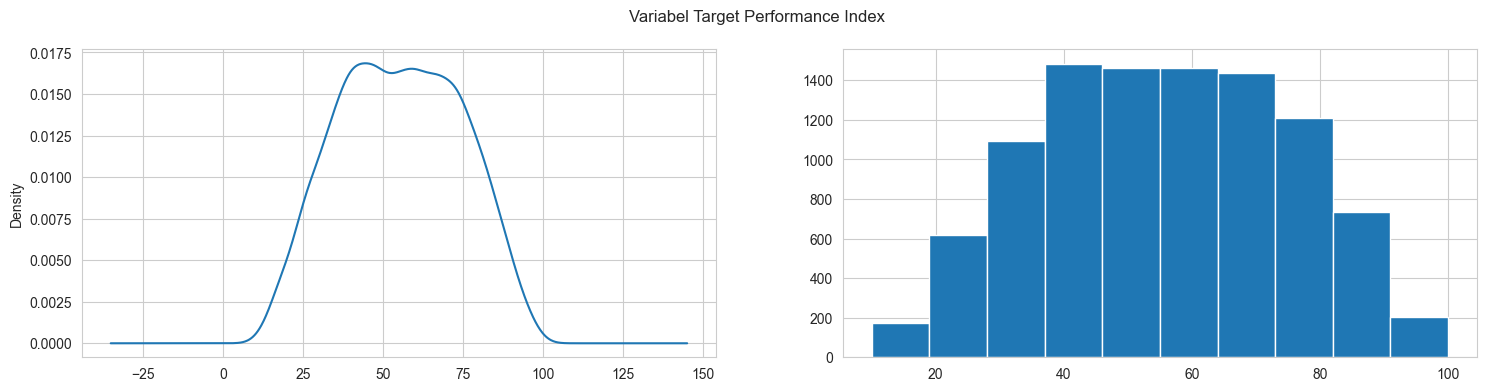

In [ ]:
f = plt.figure(figsize=(18, 4))
plt.suptitle('Variabel Target Performance Index')
f.add_subplot(1,2,1)
data['Performance Index'].plot(kind='kde')
f.add_subplot(1,2,2)
plt.hist(data['Performance Index'])
plt.show()

Berdasarkan histogram dan kurva distribusi, variabel target Performance Index memiliki distribusi yang relatif seimbang dan mendekati distribusi normal. sebagian besar nilai berada pada rentang menengah, serta tidak ditemukan indikasi skewness yang ekstrem. Kondisi ini menunjukkan bahwa variabel target cukup baik untuk digunakan dalam pemodelan regresi.

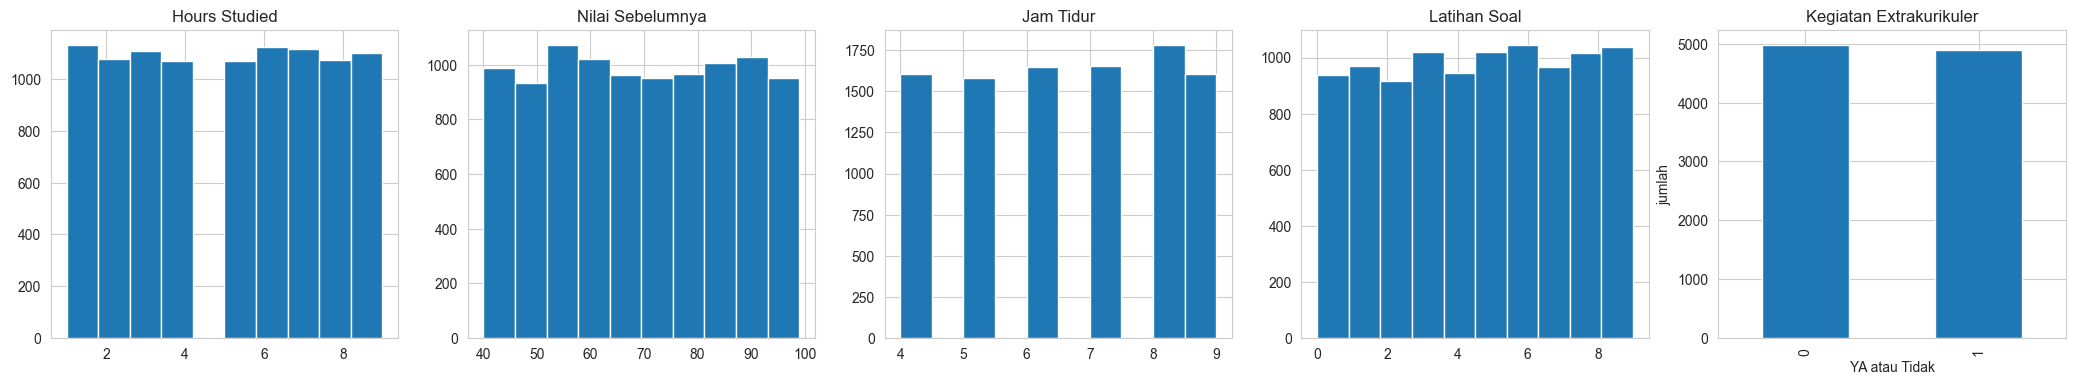

In [ ]:
f = plt.figure(figsize=(26, 4))
f.add_subplot(1,5,1)
plt.title('Hours Studied')
plt.hist(data['Hours Studied'])
f.add_subplot(1,5,2)
plt.title('Nilai Sebelumnya')
plt.hist(data['Previous Scores'])
f.add_subplot(1,5,3)
plt.title('Jam Tidur')
plt.hist(data['Sleep Hours'])
f.add_subplot(1,5,4)
plt.title('Latihan Soal')
plt.hist(data['Sample Question Papers Practiced'])
f.add_subplot(1,5,5)
plt.title('Kegiatan Ektrakurikuler')
data['Extracurricular Activities'].value_counts().plot(kind='bar')
plt.title('Kegiatan Extrakurikuler')
plt.xlabel('YA atau Tidak')
plt.ylabel('jumlah')
plt.show()


Hours Studied
- Distribusi relatif merata pada rentang 1 - 9 jam
- Tidak ada dominasi pada nilai tertentu
- Menunjukkan variasi jam belajar yang cukup baik dalam dataset

Kesimpulan:
    Variabel Hours Studied memiliki distribusi yang relatif seimbang pada seluruh rentang nilai sehingga dapat memberikan informasi yang lebih representatif dalam proses pemodelan

Previous Scores:
- Nilai tersebar dari sekitar 40 - 100
- Distribusi cukup merata
- Tidak terlihat penumpukan extrem

Kesimpulan:
    Variabel Previous Scores memiliki sebaran nilai yang cukup merata sehingga mampu merepresentasikan berbagai tingkat kemampuan akademik siswa.

Sleep Hours
- Nilainya hanya sekitar 4-9 jam
- Distribusi juga cukup seimbang

Kesimpulan:
    Variabel Sleep Hours menunjukkan distribusi yang relatif merata dengan rentang 4 hingga 9 jam per hari.

Sample Question Papers Practiced
- Sebaran 0-9 latihan.
- Tidak ada kategori yang sangat mendominasi

Kesimpulan:
    Jumlah latihan soal yang dikerjakan memiliki dsitribusi yang merata sehingga dapat digunakan untuk menganalisis pengaruh latihan terhadap performa siswa.

Extracurricular Activities
- Kelas Yes dan No hampir seimbang
- Ini bagus untuk Model

Kesimpulan:
    Variabel Extracurricular Activities memiliki proporsi kategori yang relatif seimbang antara siswa yang mengikuti dan tidak mengikuti kegiatan ekstrakurikuler.

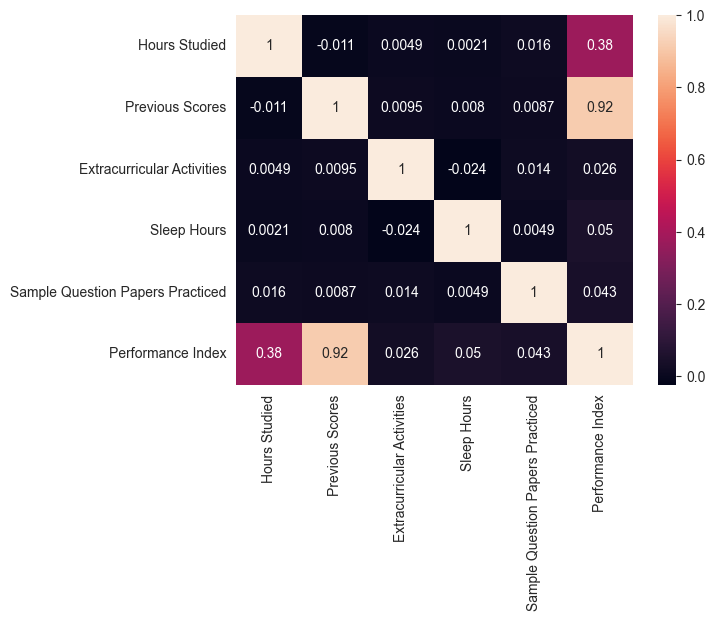

In [ ]:
korelasi_data = data.corr(numeric_only=True)
sns.heatmap(korelasi_data, cmap='rocket', annot=True)
plt.show()

Berdasarkan analisis korelasi, Previous Scores memiliki hubungan positif yang sangat kuat terhadap Performance Index dengan korelasi sebesar 0.92. Hours Studied juga menunjukkan hubungan positif dengan korelasi sebesar 0.38. Sementara itu Sleep Hours dan Sample Question Papers Practiced memiliki korelasi yang sangat rendah terhadap variabel target. Selain itu korelasi antar fitur independen relatif rendah sehingga tidak ditemukan indikasi multikolinearitas yang dapat mengganggu proses pemodelan.

# Feature Selection

Berdasarkan hasil analisis korelasi, fitur Previous Scores memiliki hubungan yang sangat kuat dengan Performance Index, sedangkan Hours Studied memiliki hubungan positif sedang. Sementara itu, SleepHours dan Sample Question Papaers Practiced menunjukkan korelasi yang relatif rendah terhadap variabel target. Namun, seluruh fitur tetap dipertahankan untuk proses pemodelan gua mengevaluasi kontribusi masing-masing variabel terhadap performa model regresi.

# Encoding kategorikal

Variabel Extracurricular Activities yang bertipe kategorikal diubah menjadi bentuk numerik menggunakan label encoding. Nilai Yes dikonversi menjadi 1 dan No menjadi 0 agar dapat digunakan dalam proses pemodelan Multiple Linear Regression.

In [39]:
encoder = LabelEncoder()

data['Extracurricular Activities'] = encoder.fit_transform(data['Extracurricular Activities'])
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


# Train Test Split

pada tahap ini, dataset dibagi menjadi data latih (training set) dan data uji (testing set). Data latih digunakan untuk membangun model Multiple Linear Regression, sedangkan data uji digunakan untuk mengevaluasi kemampuan model dalam melakukan prediksi pada data yang belum pernah dilihat sebelumnya.

Pembagian data dilakukan dengan proporsi 80% data latih dan 20% data uji. Proporsi ini dipilih karena mampu memberikan jumlah data yang cukup untuk pelatihan sekaligus menyediakan data yang memadai untuk proses evaluasi model.

In [43]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

hasil pembagian data menghasilkan 8000 data latih dan 2000 data uji

# Feature Scaling

Feature Scaling dilakukan untuk menyamakan rentang nilai antar fitur sehingga perbedaan skala tidak mempengaruhi proses pembelajaran model. Pada Penelitian ini digunakan metode Min-Max Scaling yang mengubah nilai fitur ke rentang 0 hingga 1.

In [ ]:
scaler = MinMaxScaler()

scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Model Training

pada tahap ini dilakukan pelatihan model menggunakan algoritma Multiple Linear Regression. Model dilatih menggunakan data training yang telah melalui proses preprocessing untuk mempelajari hubungan antara variabel independen dan variabel target.

In [62]:
regressor = LinearRegression()
model = regressor.fit(X_train, y_train)

In [63]:
y_pred = model.predict(X_test)

In [70]:
data_prediksi = pd.DataFrame({'Data Aktual': y_test, 'Prediksi': y_pred })
data_prediksi.head()

,Data Aktual,Prediksi
6244,74.0,73.050545
334,30.0,27.904567
9900,40.0,39.526092
3055,68.0,67.077412
6555,63.0,61.572131


# Model Evaluation

In [61]:
print('Mean Absolute Error\t:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error\t:', mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error\t:', root_mean_squared_error(y_test, y_pred))
print('r2 Square Value\t\t:', r2_score(y_test, y_pred))

Mean Absolute Error	: 1.6911921606195814
Mean Squared Error	: 4.490041091497726
Root Mean Squared Error	: 2.1189717061579008
r2 Square Value		: 0.9878120360079914


Berdasarkan hasil evaluasi, Model Multiple Linear Regression memperoleh nilai Mean Absolute Error (MAE) sebesar 1.69 dan Root Mean Squared Error (RMSE) sebesar 2.12. Nilai Error yang relatif kecil menunjukkan bahwa prediksi model memiliki tingkat kesalahan yang rendah terhadap nilai aktual.

Selain itu, model menghasilkan Rsquare sebedsar 0.9878 yang menunjukkan bahwa sekita 98.78% variasi pada variabel Performance Index dapat dijelaskan oleh variabel independen yang digunakan. Hasil ini menunjukkan bahwa model memiliki performa yang sangat baik dalam melakukan prediksi terhadap data siswa.

# Coefficient Analysis

In [65]:
print(model.coef_)

[22.86457112 60.05007788  0.62057095  2.39058384  1.75198598]


Berdasarkan hasil analisis koefisien regresi, variabel Previous Scores memiliki pengaruh terbesar terhadap Performance Index dengan nilai koefisien sebesar 60.05. Selanjutnya diikuti oleh Hours Studied dengan nilai koefisien sebesar 22.86. Sementara itu, Sleep Hours, Sample Question Papers Practiced, dan Extracurricular Activities memiliki pengaruh yang relatif lebih kecil. Hasil ini sejalan dengan analisis korelasi yang menunjukkan bahwa Previous Scores merupakan variabel yang memiliki hubungan paling kuat dengan Performance Index.

# Predict New Data

Setelah model berhasil dilatih dan dievaluasi, dilakukan penguian menggunakan data baru yang belum pernah dilihat sebelumnya. Tujuan tahap ini adalah untuk mengetahui kemampuan model dalam memprediksi nilai Performance Index berdasarkan karakteristik siswa yang diberikan.

In [86]:
data_baru = np.array([[7,85,1,7,6]])

data_baru = scaler.transform(data_baru)

hasil = model.predict(data_baru)

print('Hasil Performance Index:', hasil)

Hasil Performance Index: [77.61710358]


/home/sahrulashar/Desktop/python/machine_learning/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


# Conclusion

Proyek ini berhasil membangun model Machine Learning menggunakan algoritma Multiple Linear Regression untuk memprediksi Performance Index siswa berdasarkan beberapa faktor, yaitu Hours Studied, Previous Scores, Extracurricular Activities, Sleep Hours, dan Sample Question Papers Practiced.

Berdasarkan hasil evaluasi, model memperoleh nilai MAE sebesar 1.69, RMSE sebesar 2.12, dan R² sebesar 0.9878. Hasil tersebut menunjukkan bahwa model memiliki tingkat kesalahan prediksi yang rendah dan mampu menjelaskan sekitar 98.78% variasi pada data target.

Hasil analisis menunjukkan bahwa Previous Scores merupakan variabel yang paling berpengaruh terhadap Performance Index, diikuti oleh Hours Studied. Temuan ini konsisten dengan hasil analisis korelasi yang dilakukan pada tahap Exploratory Data Analysis (EDA).

Secara keseluruhan, model Multiple Linear Regression mampu memberikan performa prediksi yang sangat baik pada dataset Student Performance dan dapat digunakan sebagai pendekatan untuk memperkirakan performa akademik siswa berdasarkan faktor-faktor yang tersedia.